In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as sp_stats
from sparrow import Protein

plt.rcParams['svg.fonttype'] = 'none'

In [2]:
construct_stats = pd.read_csv('constructs_df.csv', index_col=0)

construct_stats['construct'] = construct_stats['construct'].astype(str)

In [3]:
# Function to calculate sequence features and predictions using sparrow
def calculate_sparrow_features(seqs_df):
    features = []
    for idx, row in seqs_df.iterrows():
        seq = row['sequence']
        construct = row['construct']
        protein = Protein(seq)
        
        # Calculate features
        f_positive = protein.fraction_positive
        f_negative = protein.fraction_negative
        aro = protein.fraction_aromatic
        ali = protein.fraction_aliphatic
        polar = protein.fraction_polar
        proline = protein.fraction_proline
        scd = protein.SCD                    # Uppercase SCD
        shd = protein.SHD                    # Uppercase SHD
        ncpr = protein.NCPR                  # Uppercase NCPR
        fcr = protein.FCR                    # Uppercase FCR
        hydrophobicity = protein.hydrophobicity
        kappa = protein.kappa
        
        # Predictions
        rg = protein.predictor.radius_of_gyration()
        re = protein.predictor.end_to_end_distance()
        mean_disorder = np.mean(protein.predictor.disorder())
        asphericity = protein.predictor.asphericity()
        scaling_exp = protein.predictor.scaling_exponent()
        prefactor = protein.predictor.prefactor()
        coil = protein.predictor.dssp_coil()
        extended = protein.predictor.dssp_extended()
        helicity = protein.predictor.dssp_helicity()
        
        features.append({
            'construct': construct,
            'f_positive': f_positive,
            'f_negative': f_negative,
            'aro': aro,
            'ali': ali,
            'polar': polar,
            'proline': proline,
            'scd': scd,
            'shd': shd,
            'NCPR': ncpr,
            'FCR': fcr,
            'hydrophobicity': hydrophobicity,
            'kappa': kappa,
            'rg': rg,
            're': re,
            'mean_disorder': mean_disorder,
            'asphericity': asphericity,
            'scaling_exponent': scaling_exp,
            'prefactor': prefactor,
            'coil': coil,
            'extended': extended,
            'helicity': helicity
        })
    return pd.DataFrame(features)

# Calculate features and predictions, then merge with construct_stats
sparrow_features = calculate_sparrow_features(construct_stats)
construct_stats = construct_stats.merge(sparrow_features, on='construct', how='left')

Error importing GPy.
 If trying to run parrot-optimize, make sure to use `pip install idptools-parrot[optimize]`


Fitted parameters: a=1.052, k=0.046, x0=25.000


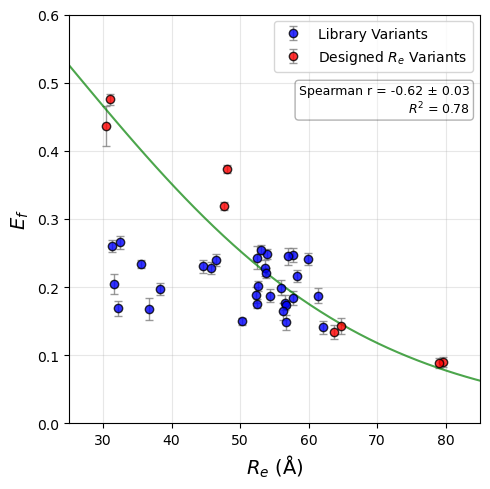

In [4]:
from scipy.optimize import curve_fit

# Define reversed sigmoid function with x-axis offset
def reversed_sigmoid(x, a, k, x0):
    return a / (1 + np.exp(k * (x - x0)))

fig, ax = plt.subplots(figsize=(5, 5))

# Separate constructs into two groups
construct_stats['construct_int'] = construct_stats['construct'].astype(int)
library = construct_stats[construct_stats['construct_int'] < 33]
Designed = construct_stats[construct_stats['construct_int'] > 33]

# Plot library sequences (<33) in blue
ax.errorbar(library['re'], library['Ef_cell'], yerr=library['Ef_cell_std'], fmt='o', 
           markeredgecolor = 'black', alpha=0.8, color='blue', capsize=3, linewidth=1, 
           ecolor='grey', label='Library Variants')

# Plot Designed sequences (>33) in red
ax.errorbar(Designed['re'], Designed['Ef_cell'], yerr=Designed['Ef_cell_std'], fmt='o', 
             markeredgecolor = 'black', alpha=0.8, color='red', capsize=3, linewidth=1, 
             ecolor='grey', label='Designed $R_e$ Variants')

# Exclude specific constructs from fit
exclude_constructs = [19, 27, 7, 23, 1, 21, 31, 25, 8, 13]

# Monte Carlo sampling for Spearman correlation
n_iterations = 1000
spearman_values = []

construct_stats_included = construct_stats[~construct_stats['construct_int'].isin(exclude_constructs)]

x = construct_stats_included['re']

for _ in range(n_iterations):
    sampled_y = []

    for idx, row in construct_stats_included.iterrows():
        # Sample from normal distribution for Ef_cell only
        sampled_y_val = np.random.normal(row['Ef_cell'], row['Ef_cell_std'])
        sampled_y.append(sampled_y_val)
    
    # Calculate Spearman correlation across all constructs for this iteration
    spearman_r_sample, _ = sp_stats.spearmanr(x, sampled_y)
    spearman_values.append(spearman_r_sample)

# Calculate mean and std of Spearman correlations
spearman_r_mean = np.mean(spearman_values)
spearman_r_std = np.std(spearman_values)

fit_data = construct_stats[~construct_stats['construct_int'].isin(exclude_constructs)]

# Fit the reversed sigmoid to filtered data
x_data = fit_data['re'].dropna().values
y_data = fit_data.loc[fit_data['re'].notna(), 'Ef_cell'].values

# Initial parameter guesses: [a, k, x0]
p0 = [0.5, 0.1, 50]
bounds = ([0, 0, 25], [np.inf, np.inf, 90])

# Fit the curve
popt, pcov = curve_fit(reversed_sigmoid, x_data, y_data, p0=p0, bounds=bounds ,maxfev=10000)

# Calculate R-squared
y_pred = reversed_sigmoid(x_data, *popt)
ss_res = np.sum((y_data - y_pred)**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r_squared = 1 - (ss_res / ss_tot)

# Plot fitted curve
x_fit = np.linspace(-50, 90, 100)
y_fit = reversed_sigmoid(x_fit, *popt)
ax.plot(x_fit, y_fit, 'green', linewidth=1.5, alpha=0.7)

# Formatting
ax.set_xlim(25, 85)
ax.set_ylim(0, .6)
ax.set_xlabel(r'$R_e$ (Å)', fontsize=14)
ax.set_ylabel(r'$E_{f}$', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', frameon=True, fontsize=10)
ax.text(0.975, 0.83, f'Spearman r = {spearman_r_mean:.2f} ± {spearman_r_std:.2f}\n$R^2$ = {r_squared:.2f}', 
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.3))

plt.tight_layout()
plt.savefig('Figure_graphs/Fig3/Ef_vs_predRe.svg')

print(f"Fitted parameters: a={popt[0]:.3f}, k={popt[1]:.3f}, x0={popt[2]:.3f}")